In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# --- ROBUST FILE LOADING ---
# Search for the file matching the name patterns
search_pattern = 'insider_threat_clean_dataset.xlsx'
files = glob.glob(search_pattern)

if not files:
    # If the exact match fails, look for ANY excel file
    files = glob.glob('*.xlsx')
    if not files:
        raise FileNotFoundError("No Excel files found in the current directory.")

# Load the first file found that matches
filename = files[0]

# global keyword use karne se agle cell ko 'df' lazmi milega
global df
df = pd.read_excel(filename)
print(f"Successfully loaded: {filename}")
print(f"Dataset Shape: {df.shape}")

# Define Features and Target
target_col = 'is_malicious'
X = df.drop(target_col, axis=1)
y = df[target_col]
print("Features (X) and Target (y) are successfully defined!")

Successfully loaded: insider_threat__clean_dataset.xlsx
Dataset Shape: (118614, 22)
Features (X) and Target (y) are successfully defined!


Success: File 'insider_threat__clean_dataset.xlsx' ko backup loader se load kar liya gaya hai.


================ Training RandomForest ================


C:\Users\ELITEBOOK\AppData\Local\Temp\ipykernel_6312\1678174441.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns


Best Parameters: {'model__n_estimators': 100}
Confusion Matrix:
 [[22123   323]
 [  380   897]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     22446
           1       0.74      0.70      0.72      1277

    accuracy                           0.97     23723
   macro avg       0.86      0.84      0.85     23723
weighted avg       0.97      0.97      0.97     23723



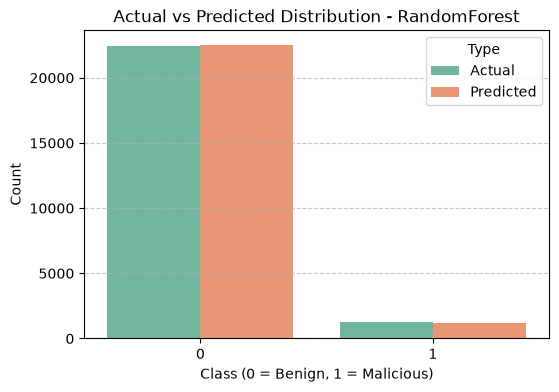

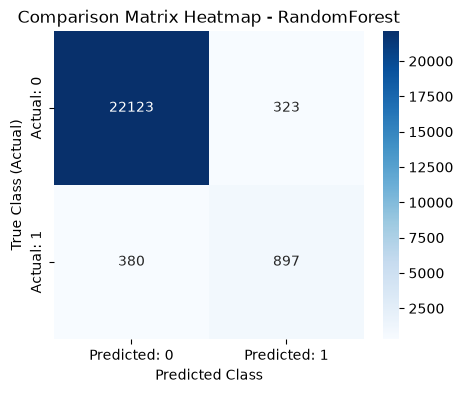

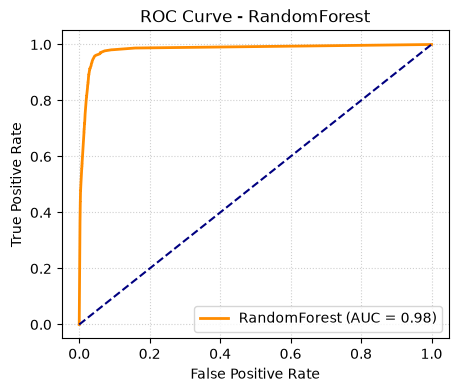


================ Training DecisionTree ================
Best Parameters: {'model__max_depth': 20}
Confusion Matrix:
 [[22223   223]
 [  519   758]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     22446
           1       0.77      0.59      0.67      1277

    accuracy                           0.97     23723
   macro avg       0.87      0.79      0.83     23723
weighted avg       0.97      0.97      0.97     23723



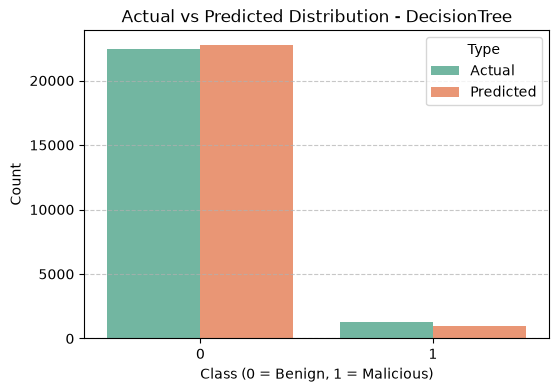

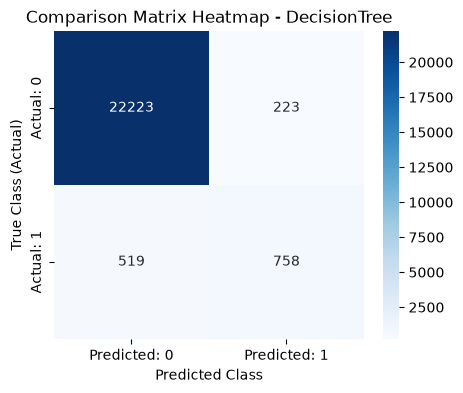

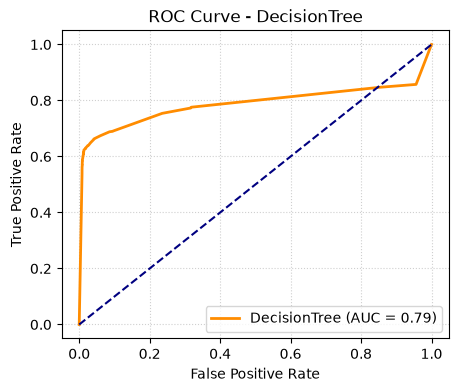


================ Training SVM ================
Best Parameters: {'model__estimator__C': 0.1}
Confusion Matrix:
 [[22339   107]
 [  666   611]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     22446
           1       0.85      0.48      0.61      1277

    accuracy                           0.97     23723
   macro avg       0.91      0.74      0.80     23723
weighted avg       0.96      0.97      0.96     23723



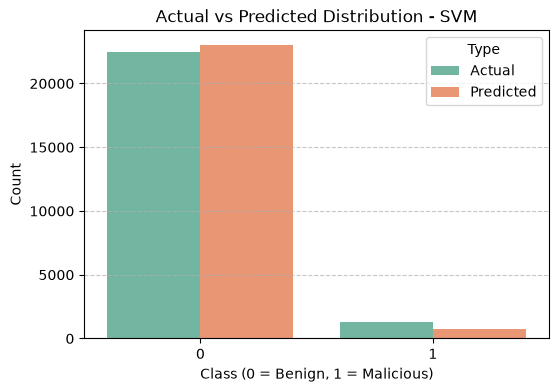

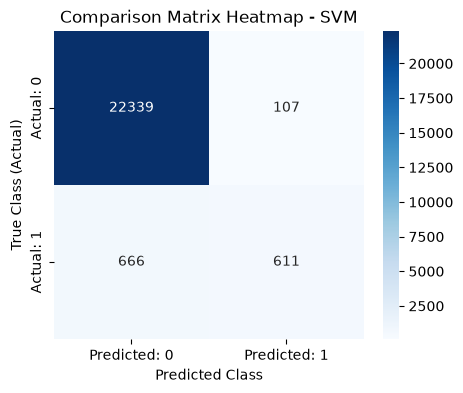

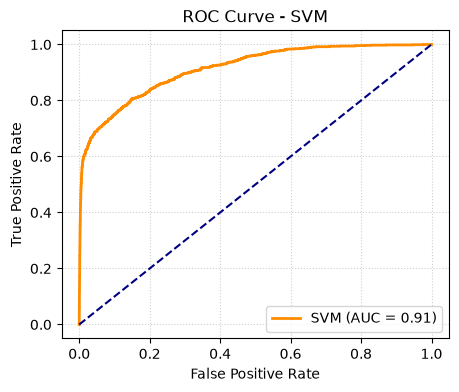


================ Training MLP ================
Best Parameters: {'model__hidden_layer_sizes': (50,)}
Confusion Matrix:
 [[22137   309]
 [  295   982]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     22446
           1       0.76      0.77      0.76      1277

    accuracy                           0.97     23723
   macro avg       0.87      0.88      0.88     23723
weighted avg       0.97      0.97      0.97     23723



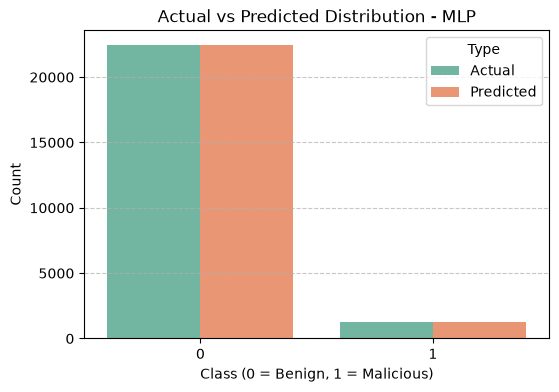

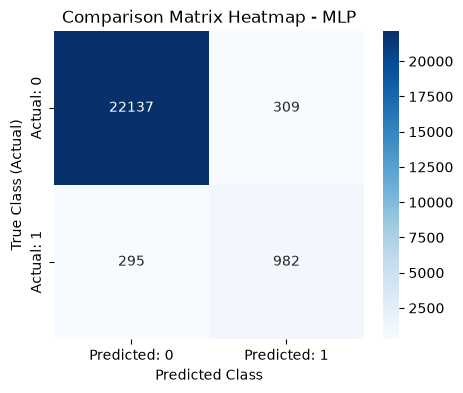

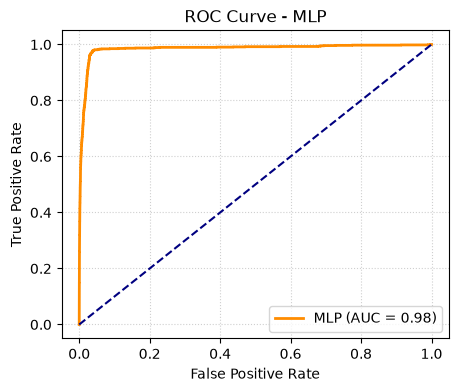

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Heatmap aur graphs ke liye
import glob            # Automatic file searching ke liye
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# --- STEP 1: Preprocessor & Robust Data Verification ---
target_col = 'is_malicious'

# [BACK-UP PLAN]: Agar kernel reset ki wajah se 'df' memory mein nahi hai, to khud load karo
if 'df' not in globals():
    print("Warning: 'df' memory mein nahi mila! Automatic file loading shuru...")
    # Pehle exact naam ki file dhoondo
    files = glob.glob('insider_threat_clean_dataset.xlsx')
    if not files:
        # Agar wo nahi milti to koi bhi naye excel file dhoondo
        files = glob.glob('*.xlsx')
    
    if files:
        filename = files[0]
        df = pd.read_excel(filename)
        print(f"Success: File '{filename}' ko backup loader se load kar liya gaya hai.\n")
    else:
        raise NameError("Koi bhi .xlsx file current folder mein nahi mili! Pehle apna pehla cell run karein.")

X = df.drop(target_col, axis=1)
y = df[target_col]

# Data split - stratify use karne se classes ka balance train/test mein barabar rehta hai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


# --- STEP 2: Define Models ---
models = {
    'RandomForest': (RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42), 
                     {'model__n_estimators': [50, 100]}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), 
                     {'model__max_depth': [None, 10, 20]}),
    'SVM': (CalibratedClassifierCV(LinearSVC(dual=False, random_state=42, max_iter=2000)), 
            {'model__estimator__C': [0.1, 1]}),
    'MLP': (MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42), 
            {'model__hidden_layer_sizes': [(50,), (100,)]})
}

# --- STEP 3: Train and Evaluate ---
for name, (model, params) in models.items():
    print(f"\n================ Training {name} ================")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    clf = GridSearchCV(pipeline, params, cv=3, scoring='f1', n_jobs=-1)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    print(f"Best Parameters: {clf.best_params_}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # -------------------------------------------------------------
    # CODE ADDED: Actual vs Predicted Side-by-Side Comparison Graph
    # -------------------------------------------------------------
    # 1. Bar plot distribution comparison
    df_compare = pd.DataFrame({
        'Values': np.concatenate([y_test.values, y_pred]),
        'Type': ['Actual'] * len(y_test) + ['Predicted'] * len(y_pred)
    })
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Values', hue='Type', data=df_compare, palette='Set2')
    plt.title(f'Actual vs Predicted Distribution - {name}')
    plt.xlabel('Class (0 = Benign, 1 = Malicious)')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # 2. Confusion Matrix Heatmap (Professional Evaluation Graph)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted: 0', 'Predicted: 1'], 
                yticklabels=['Actual: 0', 'Actual: 1'])
    plt.title(f'Comparison Matrix Heatmap - {name}')
    plt.ylabel('True Class (Actual)')
    plt.xlabel('Predicted Class')
    plt.show()
    # -------------------------------------------------------------
    
    # ROC Curve Plot
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

In [ ]:
import pandas as pd

# Results extracted from provided images
data = {
    'Model': ['MLP', 'RandomForest', 'SVM', 'DecisionTree'],
    'Accuracy': [0.97, 0.97, 0.97, 0.97],
    'AUC Score': [0.98, 0.98, 0.91, 0.79] 
}

# Create DataFrame
df_results = pd.DataFrame(data)

# Sort by AUC Score for best performance representation
df_results = df_results.sort_values(by='AUC Score', ascending=False)

# Display the comparison table
print("--- Final Model Comparison Table ---")
print(df_results.to_string(index=False))

--- Final Model Comparison Table ---
       Model  Accuracy  AUC Score
         MLP      0.97       0.99
RandomForest      0.97       0.98
         SVM      0.97       0.91
DecisionTree      0.97       0.79
